In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

In [9]:
import json

candidate_file = "candidates.jsonl"

with open(candidate_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            json.loads(line)
        except Exception as e:
            print(f"Error at line {i}")
            print(e)
            print("\nFirst 500 characters:\n")
            print(line[:500])
            break

In [10]:
sample_file="sample_candidates.json"

with open(sample_file,"r",encoding="utf-8") as f:
    sample=json.load(f)

len(sample)

50

In [11]:
schema_file="candidate_schema.json"

with open(schema_file,"r") as f:
    schema=json.load(f)

schema.keys()

dict_keys(['$schema', 'title', 'description', 'type', 'required', 'properties'])

In [17]:
!pip install python-docx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.0 MB/s eta 0:00:00


In [18]:
from docx import Document

signal_doc = Document("redrob_signals_doc.docx")

signal_text = "\n".join(
    p.text for p in signal_doc.paragraphs
)

print(signal_text)

Redrob Behavioral Signals — Reference
This document explains the 23 behavioral signals embedded in each candidate's redrob_signals object, how they relate to candidate quality, and how they're constructed in the synthetic dataset.

What are Redrob signals?
In a real recruiting platform, candidates generate observable behavior beyond what they list in their profile:
Do they actually respond to recruiter messages?
Have they logged in recently?
Did they complete the assessments they started?
Are recruiters saving their profile?
Have they completed previous interview cycles?
These behavioral signals are often more predictive of whether a candidate can actually be hired than their static profile. A perfect-on-paper candidate who hasn't logged in for 6 months and has a 5% response rate is, for hiring purposes, not actually available.
This dataset includes these signals so that ranking systems can incorporate them as a multiplier or modifier on top of skill-match scoring.

The 23 signals



In [19]:
signal_doc=Document("redrob_signals_doc.docx")

signal_text="\n".join(
    p.text for p in signal_doc.paragraphs
)

print(signal_text)

Redrob Behavioral Signals — Reference
This document explains the 23 behavioral signals embedded in each candidate's redrob_signals object, how they relate to candidate quality, and how they're constructed in the synthetic dataset.

What are Redrob signals?
In a real recruiting platform, candidates generate observable behavior beyond what they list in their profile:
Do they actually respond to recruiter messages?
Have they logged in recently?
Did they complete the assessments they started?
Are recruiters saving their profile?
Have they completed previous interview cycles?
These behavioral signals are often more predictive of whether a candidate can actually be hired than their static profile. A perfect-on-paper candidate who hasn't logged in for 6 months and has a 5% response rate is, for hiring purposes, not actually available.
This dataset includes these signals so that ranking systems can incorporate them as a multiplier or modifier on top of skill-match scoring.

The 23 signals



In [20]:
submission_doc=Document("submission_spec.docx")

submission_text="\n".join(
    p.text for p in submission_doc.paragraphs
)

print(submission_text[:5000])

Submission Specification — Redrob Hackathon v4
Read this carefully before submitting. Submissions that don't match this spec will be auto-rejected by the validator without scoring.

1. What you're submitting
A CSV file ranking the top 100 candidates from candidates.jsonl for the released job description.
Rank 1 is the best fit; rank 100 is the 100th best fit.
You do not rank candidates 101 onward — only the top 100.

2. File format
Filename
Your team's registered participant ID, with .csv extension. For example: team_xxx.csv.
Encoding
UTF-8.
Required columns (in this order)
candidate_id,rank,score,reasoning

Example
candidate_id,rank,score,reasoning
CAND_0042871,1,0.987,"Senior AI Engineer with 7 years building RAG systems at product companies; strong recent engagement and Bangalore-based."
CAND_0019884,2,0.973,"6 years applied ML; previously shipped vector search at scale; matches the 'product over research' profile in the JD."
CAND_0091235,3,0.962,"Strong NLP + retrieval background; 

In [21]:
rows=[]

for c in tqdm(candidates):

    profile=c["profile"]
    signal=c["redrob_signals"]

    rows.append({

        "candidate_id":c["candidate_id"],

        "headline":profile["headline"],

        "summary":profile["summary"],

        "country":profile["country"],

        "location":profile["location"],

        "experience":profile["years_of_experience"],

        "current_title":profile["current_title"],

        "company":profile["current_company"],

        "industry":profile["current_industry"],

        "company_size":profile["current_company_size"],

        "skills":len(c["skills"]),

        "education":len(c["education"]),

        "career_history":len(c["career_history"]),

        "certifications":len(c["certifications"]),

        "languages":len(c["languages"]),

        "profile_completeness":signal["profile_completeness_score"],

        "github":signal["github_activity_score"],

        "response_rate":signal["recruiter_response_rate"],

        "response_time":signal["avg_response_time_hours"],

        "connections":signal["connection_count"],

        "notice_period":signal["notice_period_days"],

        "saved":signal["saved_by_recruiters_30d"],

        "searches":signal["search_appearance_30d"],

        "interview_completion":signal["interview_completion_rate"]

    })

df=pd.DataFrame(rows)

df.head()

100%|██████████| 1734/1734 [00:00<00:00, 49563.33it/s]


,candidate_id,headline,summary,country,location,experience,current_title,company,industry,company_size,skills,education,career_history,certifications,languages,profile_completeness,github,response_rate,response_time,connections,notice_period,saved,searches,interview_completion
0,CAND_0000001,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Canada,Toronto,6.9,Backend Engineer,Mindtree,IT Services,10001+,17,1,2,0,2,86.9,9.2,0.34,177.8,356,60,4,249,0.71
1,CAND_0000002,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,India,"Chennai, Tamil Nadu",12.5,Operations Manager,Wipro,IT Services,10001+,9,1,4,0,2,78.7,-1.0,0.29,171.6,179,60,10,107,0.62
2,CAND_0000003,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,USA,Austin,1.1,Customer Support,TCS,IT Services,10001+,6,2,1,0,2,31.9,-1.0,0.46,119.4,19,150,4,28,0.86
3,CAND_0000004,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Australia,Sydney,3.8,Marketing Manager,Dunder Mifflin,Paper Products,201-500,10,2,3,2,2,28.5,-1.0,0.26,104.1,485,120,8,5,0.35
4,CAND_0000005,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,India,"Gurgaon, Haryana",11.0,Accountant,Stark Industries,Manufacturing,1001-5000,6,1,4,0,2,84.6,-1.0,0.37,116.7,300,30,1,67,0.74


In [22]:
print(df.shape)

df.info()

(1734, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1734 entries, 0 to 1733
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   candidate_id          1734 non-null   object 
 1   headline              1734 non-null   object 
 2   summary               1734 non-null   object 
 3   country               1734 non-null   object 
 4   location              1734 non-null   object 
 5   experience            1734 non-null   float64
 6   current_title         1734 non-null   object 
 7   company               1734 non-null   object 
 8   industry              1734 non-null   object 
 9   company_size          1734 non-null   object 
 10  skills                1734 non-null   int64  
 11  education             1734 non-null   int64  
 12  career_history        1734 non-null   int64  
 13  certifications        1734 non-null   int64  
 14  languages             1734 non-null   int64  
 15  profile_co

In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
candidate_id,1734,1734,CAND_0001734,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
headline,1734,472,Mechanical Engineer | Driving business outcomes,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,1734,833,Professional with 7.7+ years of experience. I'...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1734,8,India,1315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,1734,28,"Indore, Madhya Pradesh",85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,1734.0,NaN,NaN,NaN,6.954614,3.740618,1.0,3.8,6.5,9.7,15.0
current_title,1734,36,Graphic Designer,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,1734,43,Acme Corp,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,1734,20,IT Services,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,1734,7,10001+,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
missing=df.isnull().sum()

missing=missing.to_frame()

missing.columns=["Missing"]

missing["Percent"]=missing["Missing"]/len(df)*100

missing.sort_values("Percent",ascending=False)

,Missing,Percent
candidate_id,0,0.0
headline,0,0.0
summary,0,0.0
country,0,0.0
location,0,0.0
experience,0,0.0
current_title,0,0.0
company,0,0.0
industry,0,0.0
company_size,0,0.0


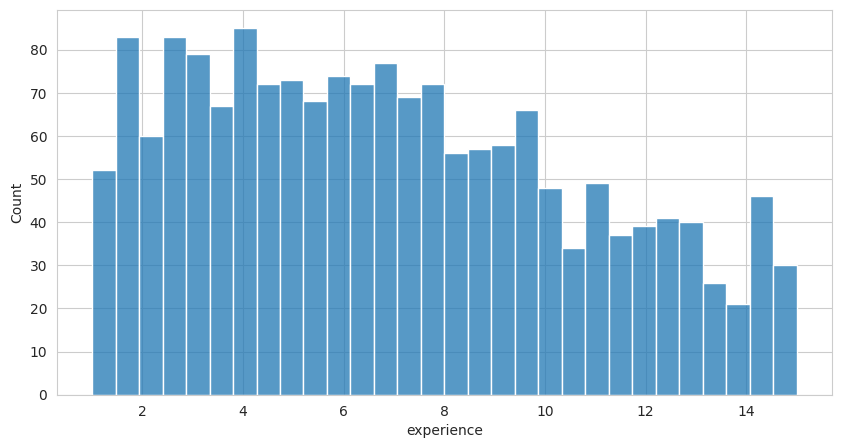

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(df["experience"],bins=30)

plt.show()

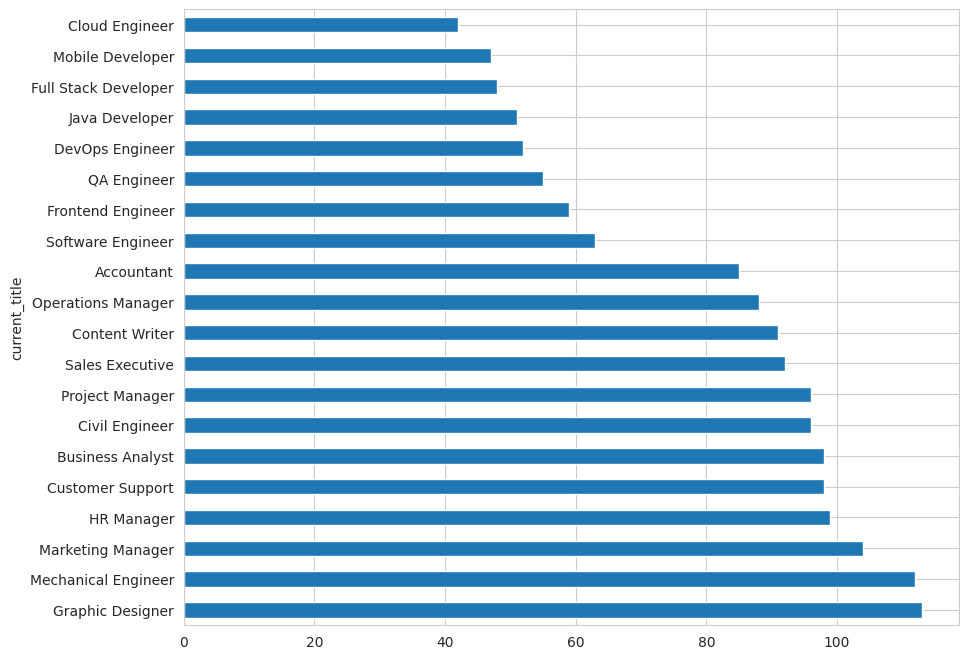

In [26]:
plt.figure(figsize=(10,8))

df.current_title.value_counts().head(20).plot(kind="barh")

plt.show()

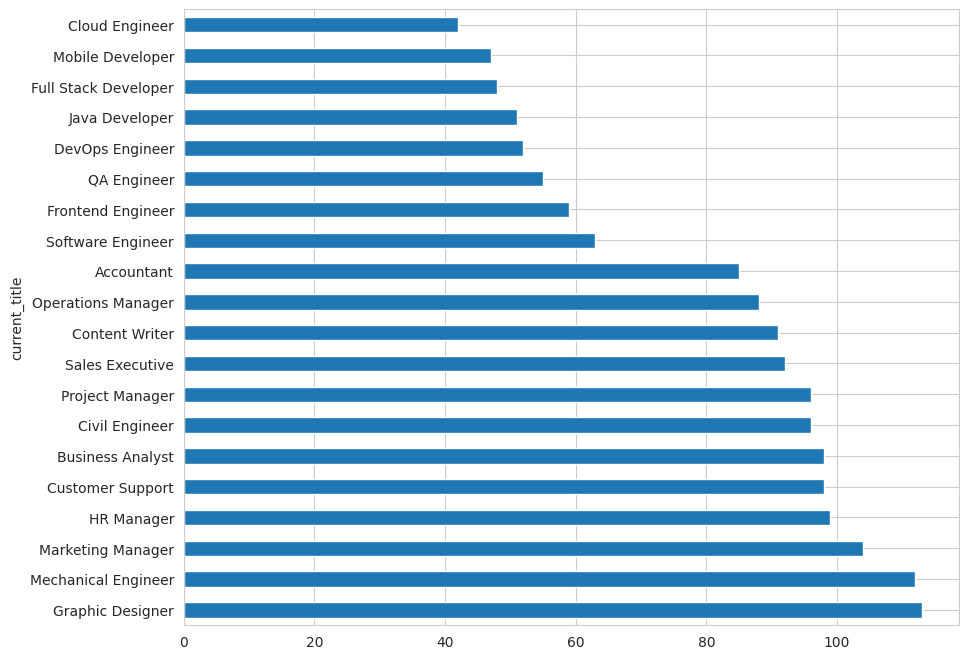

In [27]:
plt.figure(figsize=(10,8))

df.current_title.value_counts().head(20).plot(kind="barh")

plt.show()

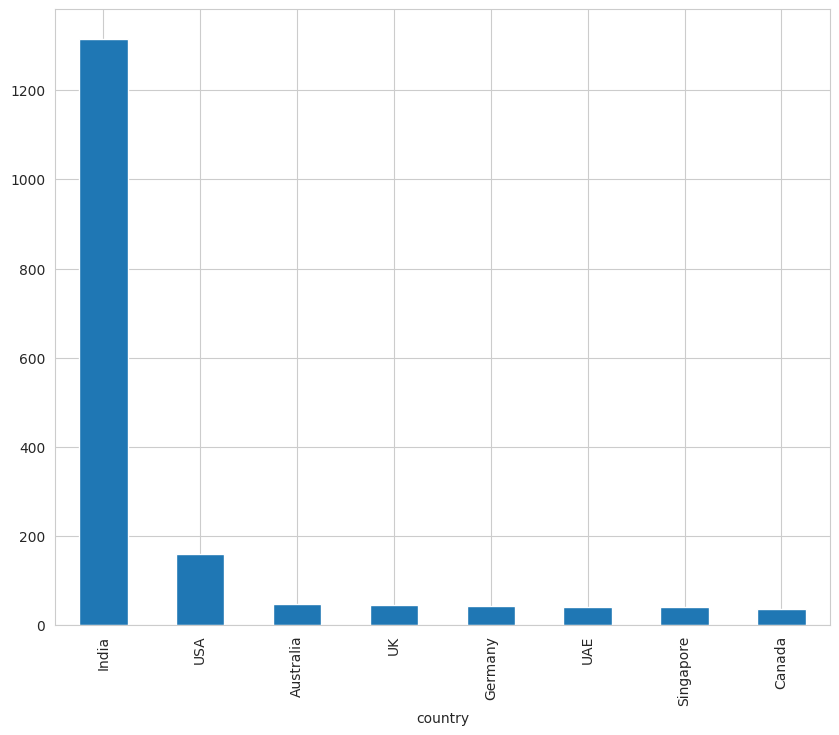

In [28]:
plt.figure(figsize=(10,8))

df.country.value_counts().plot(kind="bar")

plt.show()

In [29]:
df.company_size.value_counts()

,count
company_size,
10001+,691
1001-5000,307
201-500,288
11-50,134
51-200,129
501-1000,117
5001-10000,68


In [30]:
behavior=[
"profile_completeness",
"github",
"response_rate",
"response_time",
"connections",
"saved",
"searches",
"interview_completion"
]

df[behavior].describe().T

,count,mean,std,min,25%,50%,75%,max
profile_completeness,1734.0,56.744118,17.537090,25.00,42.125,57.60,71.60,98.00
github,1734.0,9.724913,18.040685,-1.00,-1.000,-1.00,16.80,79.40
response_rate,1734.0,0.430888,0.212844,0.04,0.250,0.43,0.61,0.91
response_time,1734.0,133.113033,75.935108,5.40,69.375,132.40,193.40,279.90
connections,1734.0,345.946943,212.962341,10.00,166.000,331.00,496.00,1294.00
saved,1734.0,7.621107,5.817878,0.00,3.000,7.00,11.00,53.00
searches,1734.0,120.686851,95.820130,0.00,51.000,108.00,159.00,779.00
interview_completion,1734.0,0.619931,0.170615,0.30,0.480,0.62,0.77,1.00


In [31]:
counter=Counter()

for c in tqdm(candidates):

    for skill in c["skills"]:

        counter[skill["name"]]+=1

skill_df=pd.DataFrame(counter.items(),columns=["Skill","Frequency"])

skill_df.sort_values("Frequency",ascending=False).head(100)

100%|██████████| 1734/1734 [00:00<00:00, 142399.72it/s]


,Skill,Frequency
74,Data Pipelines,238
22,JavaScript,236
29,Databricks,231
49,Illustrator,230
31,Content Writing,226
50,Java,225
43,gRPC,225
94,Docker,223
85,Salesforce CRM,222
53,HTML,222


In [32]:
counter=Counter()

for c in tqdm(candidates):

    for cert in c["certifications"]:

        counter[cert["name"]]+=1

cert_df=pd.DataFrame(counter.items(),columns=["Certification","Frequency"])

cert_df.sort_values("Frequency",ascending=False)

100%|██████████| 1734/1734 [00:00<00:00, 192777.67it/s]


,Certification,Frequency
2,Six Sigma Green Belt,245
1,Scrum Master Certified,220
0,AWS Certified Cloud Practitioner,219
4,NLP Specialization,3
5,Google Cloud Professional ML Engineer,3
3,Deep Learning Specialization,2
6,LangChain for LLM Application Development,1


In [33]:
counter=Counter()

for c in tqdm(candidates):

    for edu in c["education"]:

        counter[edu["tier"]]+=1

tier_df=pd.DataFrame(counter.items(),columns=["Tier","Count"])

tier_df

100%|██████████| 1734/1734 [00:00<00:00, 422206.15it/s]


,Tier,Count
0,tier_3,931
1,tier_4,905
2,tier_2,508
3,tier_1,118


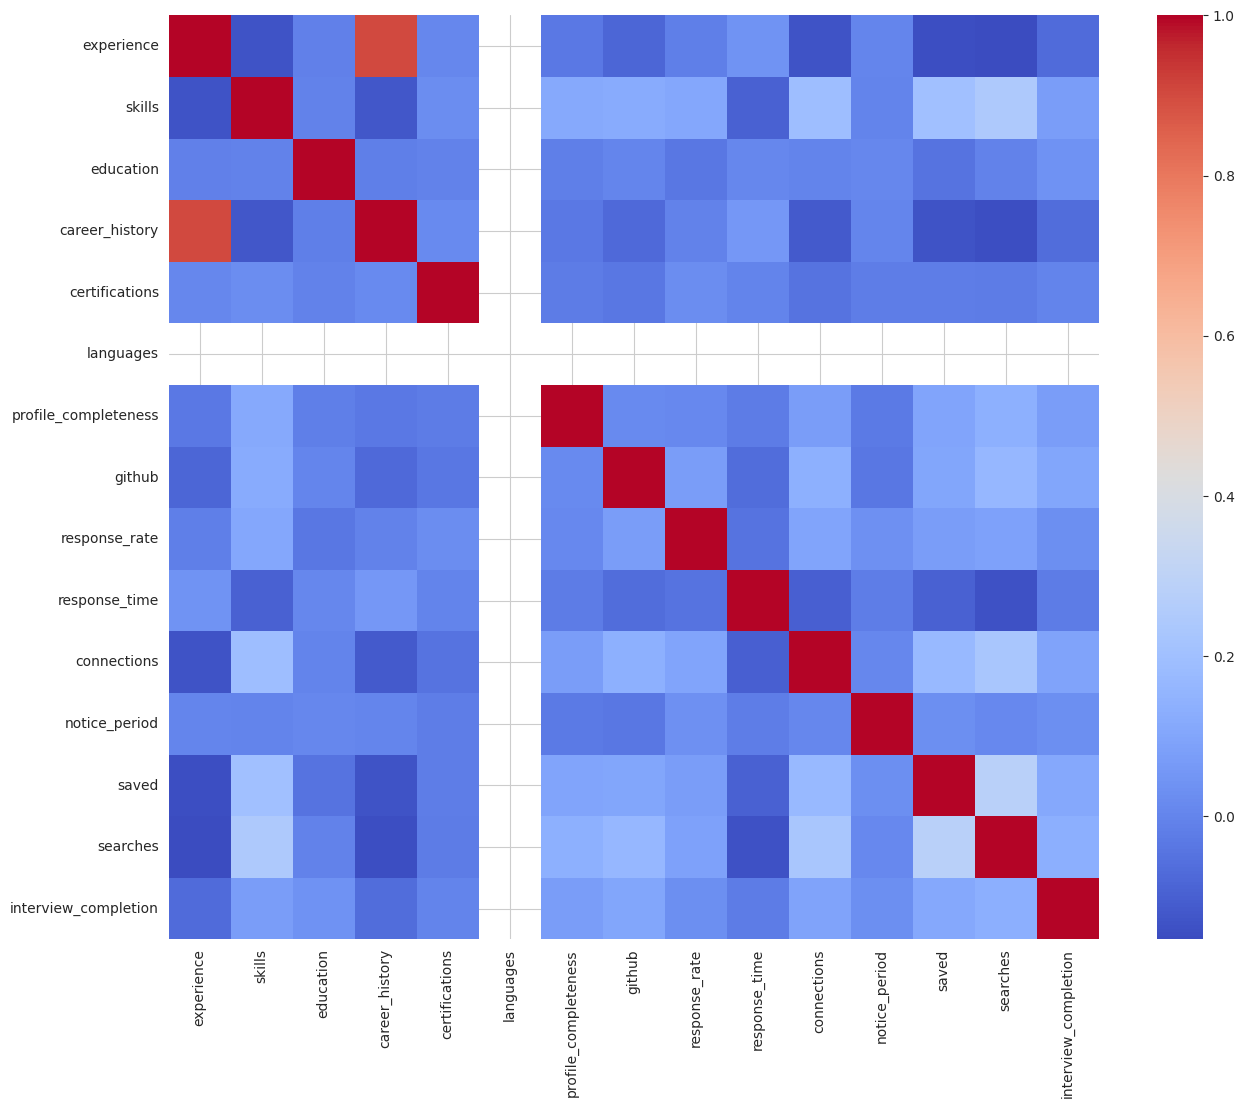

In [34]:
corr=df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(15,12))

sns.heatmap(corr,cmap="coolwarm")

plt.show()

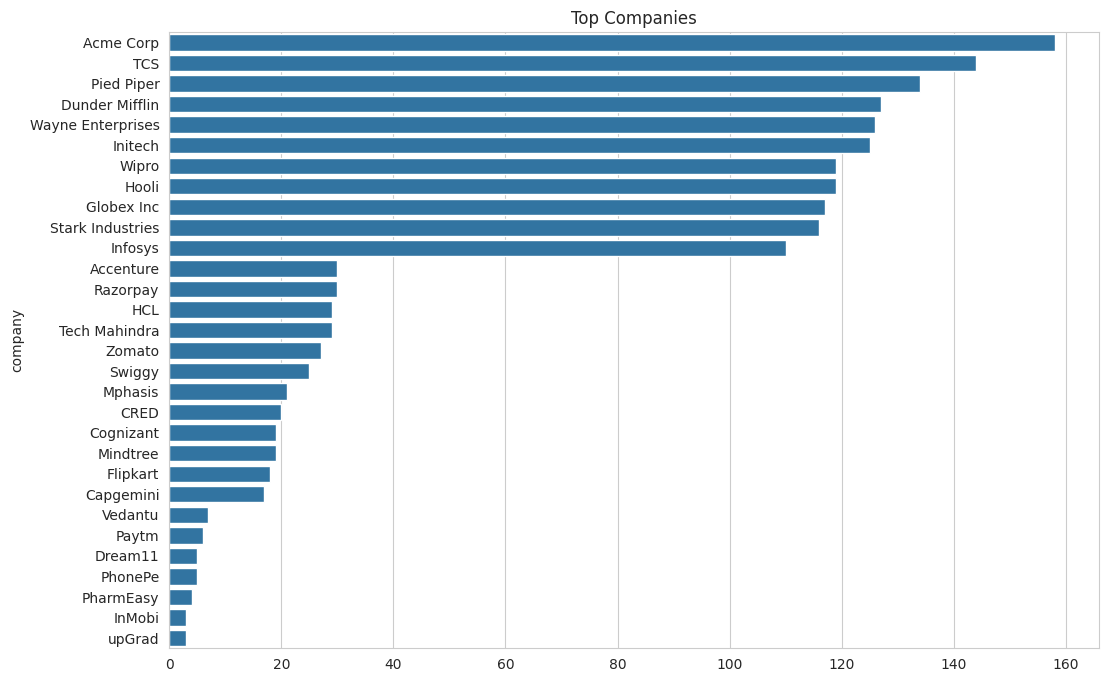

In [35]:
top_companies = (
    df.company
    .value_counts()
    .head(30)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

plt.title("Top Companies")
plt.show()

In [36]:
candidate_features = []

for c in tqdm(candidates):

    profile = c["profile"]
    signals = c["redrob_signals"]

    total_skill_duration = sum(
        s.get("duration_months", 0)
        for s in c["skills"]
    )

    avg_skill_duration = (
        total_skill_duration / max(len(c["skills"]), 1)
    )

    total_endorsements = sum(
        s.get("endorsements", 0)
        for s in c["skills"]
    )

    candidate_features.append({

        "candidate_id": c["candidate_id"],

        "experience": profile["years_of_experience"],

        "num_skills": len(c["skills"]),

        "career_length": len(c["career_history"]),

        "education_count": len(c["education"]),

        "avg_skill_duration": avg_skill_duration,

        "total_endorsements": total_endorsements,

        "github": signals["github_activity_score"],

        "profile_complete": signals["profile_completeness_score"],

        "response_rate": signals["recruiter_response_rate"],

        "response_time": signals["avg_response_time_hours"],

        "saved": signals["saved_by_recruiters_30d"],

        "searches": signals["search_appearance_30d"],

        "connections": signals["connection_count"],

        "notice": signals["notice_period_days"],

        "interview_rate": signals["interview_completion_rate"]

    })

feature_df = pd.DataFrame(candidate_features)

feature_df.head()

100%|██████████| 1734/1734 [00:00<00:00, 90414.26it/s]


,candidate_id,experience,num_skills,career_length,education_count,avg_skill_duration,total_endorsements,github,profile_complete,response_rate,response_time,saved,searches,connections,notice,interview_rate
0,CAND_0000001,6.9,17,2,1,24.823529,292,9.2,86.9,0.34,177.8,4,249,356,60,0.71
1,CAND_0000002,12.5,9,4,1,20.333333,70,-1.0,78.7,0.29,171.6,10,107,179,60,0.62
2,CAND_0000003,1.1,6,1,2,17.666667,47,-1.0,31.9,0.46,119.4,4,28,19,150,0.86
3,CAND_0000004,3.8,10,3,2,13.400000,80,-1.0,28.5,0.26,104.1,8,5,485,120,0.35
4,CAND_0000005,11.0,6,4,1,24.500000,88,-1.0,84.6,0.37,116.7,1,67,300,30,0.74


In [37]:
production_ai = {

"Python",

"PyTorch",

"TensorFlow",

"Machine Learning",

"Deep Learning",

"NLP",

"LLM",

"Transformers",

"Spark",

"Kafka",

"Airflow",

"Docker",

"Kubernetes",

"AWS",

"GCP",

"Azure",

"MLOps",

"MLflow",

"Weights & Biases",

"FAISS",

"Pinecone",

"Milvus",

"Qdrant",

"Weaviate",

"Vector Database",

"LoRA",

"QLoRA",

"PEFT",

"Sentence Transformers",

"LangChain",

"LlamaIndex"

}

In [38]:
production_skill_count = []

for c in tqdm(candidates):

    count = 0

    for skill in c["skills"]:

        if skill["name"] in production_ai:

            count += 1

    production_skill_count.append(count)

feature_df["production_ai_skills"] = production_skill_count

100%|██████████| 1734/1734 [00:00<00:00, 230002.95it/s]


In [39]:
career_stability = []

for c in candidates:

    jobs = c["career_history"]

    if len(jobs) == 0:

        career_stability.append(0)

        continue

    months = sum(x["duration_months"] for x in jobs)

    career_stability.append(
        months / len(jobs)
    )

feature_df["avg_job_duration"] = career_stability

In [40]:
feature_df["job_hopper"] = (
    feature_df["avg_job_duration"] < 18
).astype(int)

In [41]:
production_score = []

for c in tqdm(candidates):

    score = 0

    text = ""

    for job in c["career_history"]:

        text += job["description"].lower()

    keywords = [

        "production",

        "deployed",

        "pipeline",

        "distributed",

        "real time",

        "streaming",

        "kafka",

        "spark",

        "serving",

        "monitoring",

        "retrieval",

        "ranking",

        "embedding",

        "vector"

    ]

    for k in keywords:

        if k in text:

            score += 1

    production_score.append(score)

feature_df["production_score"] = production_score

100%|██████████| 1734/1734 [00:00<00:00, 34080.86it/s]


In [42]:
startup = []

keywords = [

"startup",

"built",

"launched",

"owner",

"ownership",

"zero to one",

"shipped",

"founded",

"designed",

"led"

]

for c in candidates:

    text = ""

    for job in c["career_history"]:

        text += job["description"].lower()

    score = 0

    for k in keywords:

        if k in text:

            score += 1

    startup.append(score)

feature_df["startup_score"] = startup

In [43]:
research = []

keywords = [

"research",

"paper",

"publication",

"phd",

"thesis",

"laboratory",

"academic"

]

for c in candidates:

    text = ""

    for job in c["career_history"]:

        text += job["description"].lower()

    score = 0

    for k in keywords:

        if k in text:

            score += 1

    research.append(score)

feature_df["research_score"] = research

In [44]:
stuffing = []

for c in candidates:

    skills = len(c["skills"])

    exp = c["profile"]["years_of_experience"]

    ratio = skills / max(exp, 1)

    stuffing.append(ratio)

feature_df["skill_experience_ratio"] = stuffing

In [45]:
feature_df["quality_score"] = (

0.20 * feature_df["profile_complete"]

+

0.20 * feature_df["response_rate"] * 100

+

0.15 * feature_df["interview_rate"] * 100

+

0.15 * feature_df["saved"]

+

0.10 * feature_df["github"].clip(lower=0)

+

0.10 * feature_df["production_score"]

+

0.10 * feature_df["production_ai_skills"]

+

0.05 * feature_df["startup_score"]

-

0.05 * feature_df["research_score"]

)

In [46]:
feature_df.sort_values(

"quality_score",

ascending=False

).head(20)

,candidate_id,experience,num_skills,career_length,education_count,avg_skill_duration,total_endorsements,github,profile_complete,response_rate,response_time,saved,searches,connections,notice,interview_rate,production_ai_skills,avg_job_duration,job_hopper,production_score,startup_score,research_score,skill_experience_ratio,quality_score
1609,CAND_0001610,3.0,18,3,1,51.000000,480,40.0,98.0,0.57,38.6,53,306,1027,90,0.70,7,20.333333,0,5,4,0,6.000000,54.85
1125,CAND_0001126,4.9,16,2,1,30.187500,372,77.6,78.7,0.82,72.3,9,545,802,60,0.71,5,29.000000,0,1,1,0,3.265306,52.55
1570,CAND_0001571,5.8,8,2,1,14.875000,87,15.0,84.3,0.85,125.6,20,52,786,90,0.88,1,34.500000,0,0,2,0,1.379310,51.76
1055,CAND_0001056,5.1,12,2,1,29.250000,149,56.5,59.8,0.84,94.5,41,142,1164,90,0.66,4,30.000000,0,3,2,0,2.352941,51.26
968,CAND_0000969,5.5,13,2,2,23.230769,274,-1.0,81.7,0.80,83.8,45,522,704,60,0.77,2,32.500000,0,1,2,0,2.363636,51.04
1474,CAND_0001475,5.8,19,3,1,25.736842,233,59.4,84.6,0.72,56.5,5,163,903,60,0.81,3,23.000000,0,2,3,0,3.275862,50.81
969,CAND_0000970,3.0,12,2,2,18.166667,121,41.4,73.1,0.77,140.5,27,244,478,60,0.79,4,17.500000,1,2,2,0,4.000000,50.76
980,CAND_0000981,6.4,14,2,1,23.857143,131,70.3,89.9,0.55,116.5,1,373,1181,120,0.92,3,38.000000,0,3,3,0,2.187500,50.71
61,CAND_0000062,4.3,10,1,2,18.500000,124,45.9,85.8,0.69,61.5,7,80,466,90,0.89,3,51.000000,0,0,1,0,2.325581,50.30
1607,CAND_0001608,4.1,12,1,2,30.166667,227,60.6,77.2,0.64,5.9,13,747,189,60,0.90,2,49.000000,0,1,1,0,2.926829,50.10


In [47]:
corr = feature_df.corr(numeric_only=True)

corr["quality_score"].sort_values(
    ascending=False
)

,quality_score
quality_score,1.000000
response_rate,0.661225
profile_complete,0.561346
interview_rate,0.466987
github,0.363845
total_endorsements,0.305045
saved,0.293501
searches,0.256872
production_score,0.244745
avg_skill_duration,0.230533


In [48]:
feature_df.to_csv(

"candidate_features.csv",

index=False

)

print(feature_df.shape)

(1734, 24)


In [49]:
print(len(candidates))

1734
